# 1.A : Model

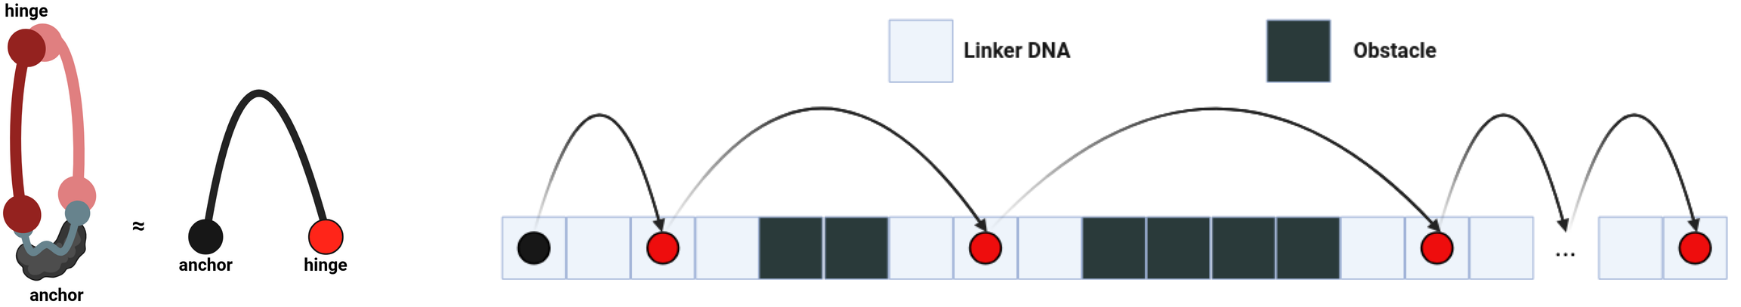

In [3]:
from IPython.display import Image, display
display(Image(filename="fig1_a.png"))

# 1.B : Jumps (Ryu (data + fitted) + 3 trajectories (Ryu + mu2 + theta2))

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import gamma
plt.rcParams["font.size"] = 16


# ─────────────────────────────────────────────
# Conversion nm -> bp
# ─────────────────────────────────────────────
conv = (0.246 + 0.255 + 0.257) / 3  # nm per bp


def proba_gamma(mu: float, theta: float, L: float) -> float:
    alpha_gamma = mu**2 / theta**2
    beta_gamma = theta**2 / mu
    return gamma.pdf(L, a=alpha_gamma, scale=beta_gamma)


# ─────────────────────────────────────────────
# Données expérimentales (converties en bp)
# ─────────────────────────────────────────────
x_nm = np.arange(0, 150, 10)
x = x_nm / conv 
y = np.array(
    [10, 140, 240, 200, 130, 125, 90, 60, 30, 25, 20, 10, 15, 7, 5], 
    dtype=float
)
y /= np.sum(y)

# ─────────────────────────────────────────────
# Axe fin (bp)
# ─────────────────────────────────────────────
x_fine_nm = np.arange(0, 150, 1)
x_fine_2 = x_fine_nm / conv


# ─────────────────────────────────────────────
# Fit
# ─────────────────────────────────────────────
popt, pcov = curve_fit(
    lambda x, mu, theta: proba_gamma(mu, theta, x) * (10 / conv),
    x,
    y,
    p0=[80, 40],  # en bp maintenant
    bounds=(0, np.inf),
    maxfev=10000
)

mu, theta = popt
print(f"mu={mu} and theta ={theta}")


# ─────────────────────────────────────────────
# PDF continue
# ─────────────────────────────────────────────
p = proba_gamma(mu, theta, x_fine_2)

bin_width = (10 / conv)  # bin en bp
p_plot = p * bin_width


# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────
plt.figure(figsize=(8,6), dpi=1200)

plt.bar(
    x, y,
    width=(8 / conv),
    edgecolor="black",
    color="red",
    alpha=0.5,
    label="Data from Ryu et al. 2022"
)

plt.plot(
    x_fine_2,
    p_plot,
    lw=2,
    color="red",
    label=f"Gamma fit : (μ,θ) = ({150:.0f},{theta:.0f}) bp"
)

plt.xlabel("Step size (bp)")
plt.ylabel("Probability")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

mu=153.04832815111186 and theta =100.02302575647388


# 1.C : Properties of the Gamma distrib

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from nucleo.simulation.probabilities import proba_gamma

plt.rcParams["font.size"] = 16

x_fine = np.arange(0, 500, 1)
params = [
    (100, 20),
    (200, 20),
    (200, 200),
]

cmap = plt.cm.Reds
colors = [cmap(0.4), cmap(0.65), cmap(0.9)]

plt.figure(figsize=(8,6), dpi=1200)

for (mu, theta), color in zip(params, colors):
    pb = proba_gamma(mu=mu, theta=theta, L=x_fine)
    
    plt.plot(
        x_fine,
        pb,
        lw=2.5,
        color=color,
        label=f"(μ,θ) = ({mu},{theta})"
    )

plt.xlabel(r"Step size $\Delta x (\sigma)$")
plt.ylabel("Probability density")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right", ncols=1)
plt.tight_layout()
plt.show()

# 1.D : Chromatin lanscapes (homogeneous + periodic + random)

In [6]:
from nucleo.simulation.chromatin import alpha_random, alpha_periodic, alpha_homogen
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams["font.size"] = 16

# Values in nm
s = 150
l = 10
alphao = 0
alphaf = 1
Lmin = 0
Lmax = 500
bps = 1

# Landscapes
obs_1 = alpha_homogen(s=s, l=l, alphao=alphao, alphaf=alphaf, alphar=0, Kp=0, Lmin=0, Lmax=Lmax, bps=bps)
obs_2 = alpha_periodic(s=s, l=l, alphao=alphao, alphaf=alphaf, Lmin=0, Lmax=Lmax, bps=bps)
obs_3 = alpha_random(s=s, l=l, alphao=alphao, alphaf=alphaf, Lmin=0, Lmax=Lmax, bps=bps)
chrom = np.arange(0, len(obs_1), 1)

# -------------------------------
# Homogeneous
# -------------------------------
plt.figure(figsize=(8,5), dpi=1200)

plt.plot(chrom, obs_1, c="b", lw=3)
plt.title("Homogeneous")
plt.xlabel("x")
plt.ylabel(r"Accessibility $\alpha$")
plt.ylim([-0.1, 1.1])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# -------------------------------
# Periodic
# -------------------------------
plt.figure(figsize=(8,5), dpi=1200)

plt.step(chrom, obs_2, c="b", lw=3)
plt.title("Periodic")
plt.xlabel("x")
# plt.ylabel(r"Accessibility $\alpha$")
plt.ylim([-0.1, 1.1])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# -------------------------------
# Random
# -------------------------------
plt.figure(figsize=(8,5), dpi=1200)

plt.step(chrom, obs_3, c="b", lw=3)
plt.title("Random")
plt.xlabel("x")
# plt.ylabel(r"Accessibility $\alpha$")
plt.ylim([-0.1, 1.1])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# 1.E : Linker and RoadBlocks distribution

In [7]:
# Librairies
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from polars import selectors as cs
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from nucleo.metrics.utils import listoflist_into_matrix
plt.rcParams["font.size"] = 16

# Data
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/2026-03-12__PC/nucleo__fig1_0")
paths = [str(p) for p in root.rglob("*.parquet")]
df_sorted = (
    pl.scan_parquet(paths)
    .select(
        cs.string() | cs.boolean() |  cs.integer() |  cs.float() | 
        pl.col("s_points") | pl.col("s_distrib") | pl.col("l_points") | pl.col("l_distrib")
      )
    .collect()
    .sort(by=["landscape", "bpmin", "l"],
          descending=[False, False, False]
        )
      .filter(
          pl.col("landscape") == "random"
      )
)

# Obstacles
obs_points_data = df_sorted["s_points"].to_list()
obs_points_data = listoflist_into_matrix(obs_points_data)
obs_points = np.nanmean(obs_points_data,axis=0)

obs_distrib_data = df_sorted["s_distrib"].to_list()
obs_distrib_data = listoflist_into_matrix(obs_distrib_data)
obs_distrib = np.nanmean(obs_distrib_data,axis=0)

# To roadblocks
mask_s = (obs_distrib != 0)
obs_points = obs_points[mask_s]
obs_distrib = obs_distrib[mask_s]
roadblocks_points = obs_points//s
roadblocks_distrib = obs_distrib

# Linkers
link_points_data = df_sorted["l_points"].to_list()
link_points_data = listoflist_into_matrix(link_points_data)
link_points = np.nanmean(link_points_data,axis=0)
link_points = np.concatenate((np.array([0.0]), link_points))

link_distrib_data = df_sorted["l_distrib"].to_list()
link_distrib_data = listoflist_into_matrix(link_distrib_data)
link_distrib = np.nanmean(link_distrib_data,axis=0)


# Theory
from scipy.special import factorial

def th_linkers(l, lmoy):
    A = lmoy * (1 - np.exp(-1 / lmoy))
    P = A * (np.exp(1 / lmoy) - 1) * np.exp(-l / lmoy)
    P = P / np.sum(P)
    P0 = np.array([1 - A])
    PF = np.concatenate((P0, P))
    return PF / np.sum(PF)


def th_roadblocks(m, lmoy):
    m = np.atleast_1d(m).astype(int)
    A = np.exp(1 / lmoy) - 1
    P = np.array([1 / (lmoy**mi * A * factorial(mi)) for mi in m], dtype=float)
    return P / np.sum(P)


# Plot
fig, axes = plt.subplots(ncols=1 , nrows=2, figsize=(8,6), dpi=1200)

s = 150
lmoy = 10

theory_distrib = th_linkers(link_points[1:], lmoy)

axes[0].plot(link_points[:-1], link_distrib, label='Simulation',
             color='lightblue', alpha=1, marker='o', lw=2)
axes[0].plot(link_points, theory_distrib, label="Theory", 
             color='black', ls="--", lw=2)

axes[0].set_xlabel('Size of linkers')
axes[0].set_ylabel('Distribution')
axes[0].set_xlim([-1, 45])
# axes[0].set_ylim([-0.10, 0.25])
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right")


theory_distrib = th_roadblocks(roadblocks_points, lmoy)

axes[1].plot(roadblocks_points, roadblocks_distrib, label='Simulation',
      color='darkslategray', alpha=1, marker='o', lw=2)
axes[1].plot(roadblocks_points, theory_distrib, label="Theory",
             color='black', ls="--", lw=2)

axes[1].set_xticks(np.arange(1, 6, 1, dtype=int))
axes[1].set_ylim([-0.10, 1.10])
axes[1].set_xlabel("Consecutive roadblocks")
axes[1].set_ylabel('Distribution')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

# FIGURE 1

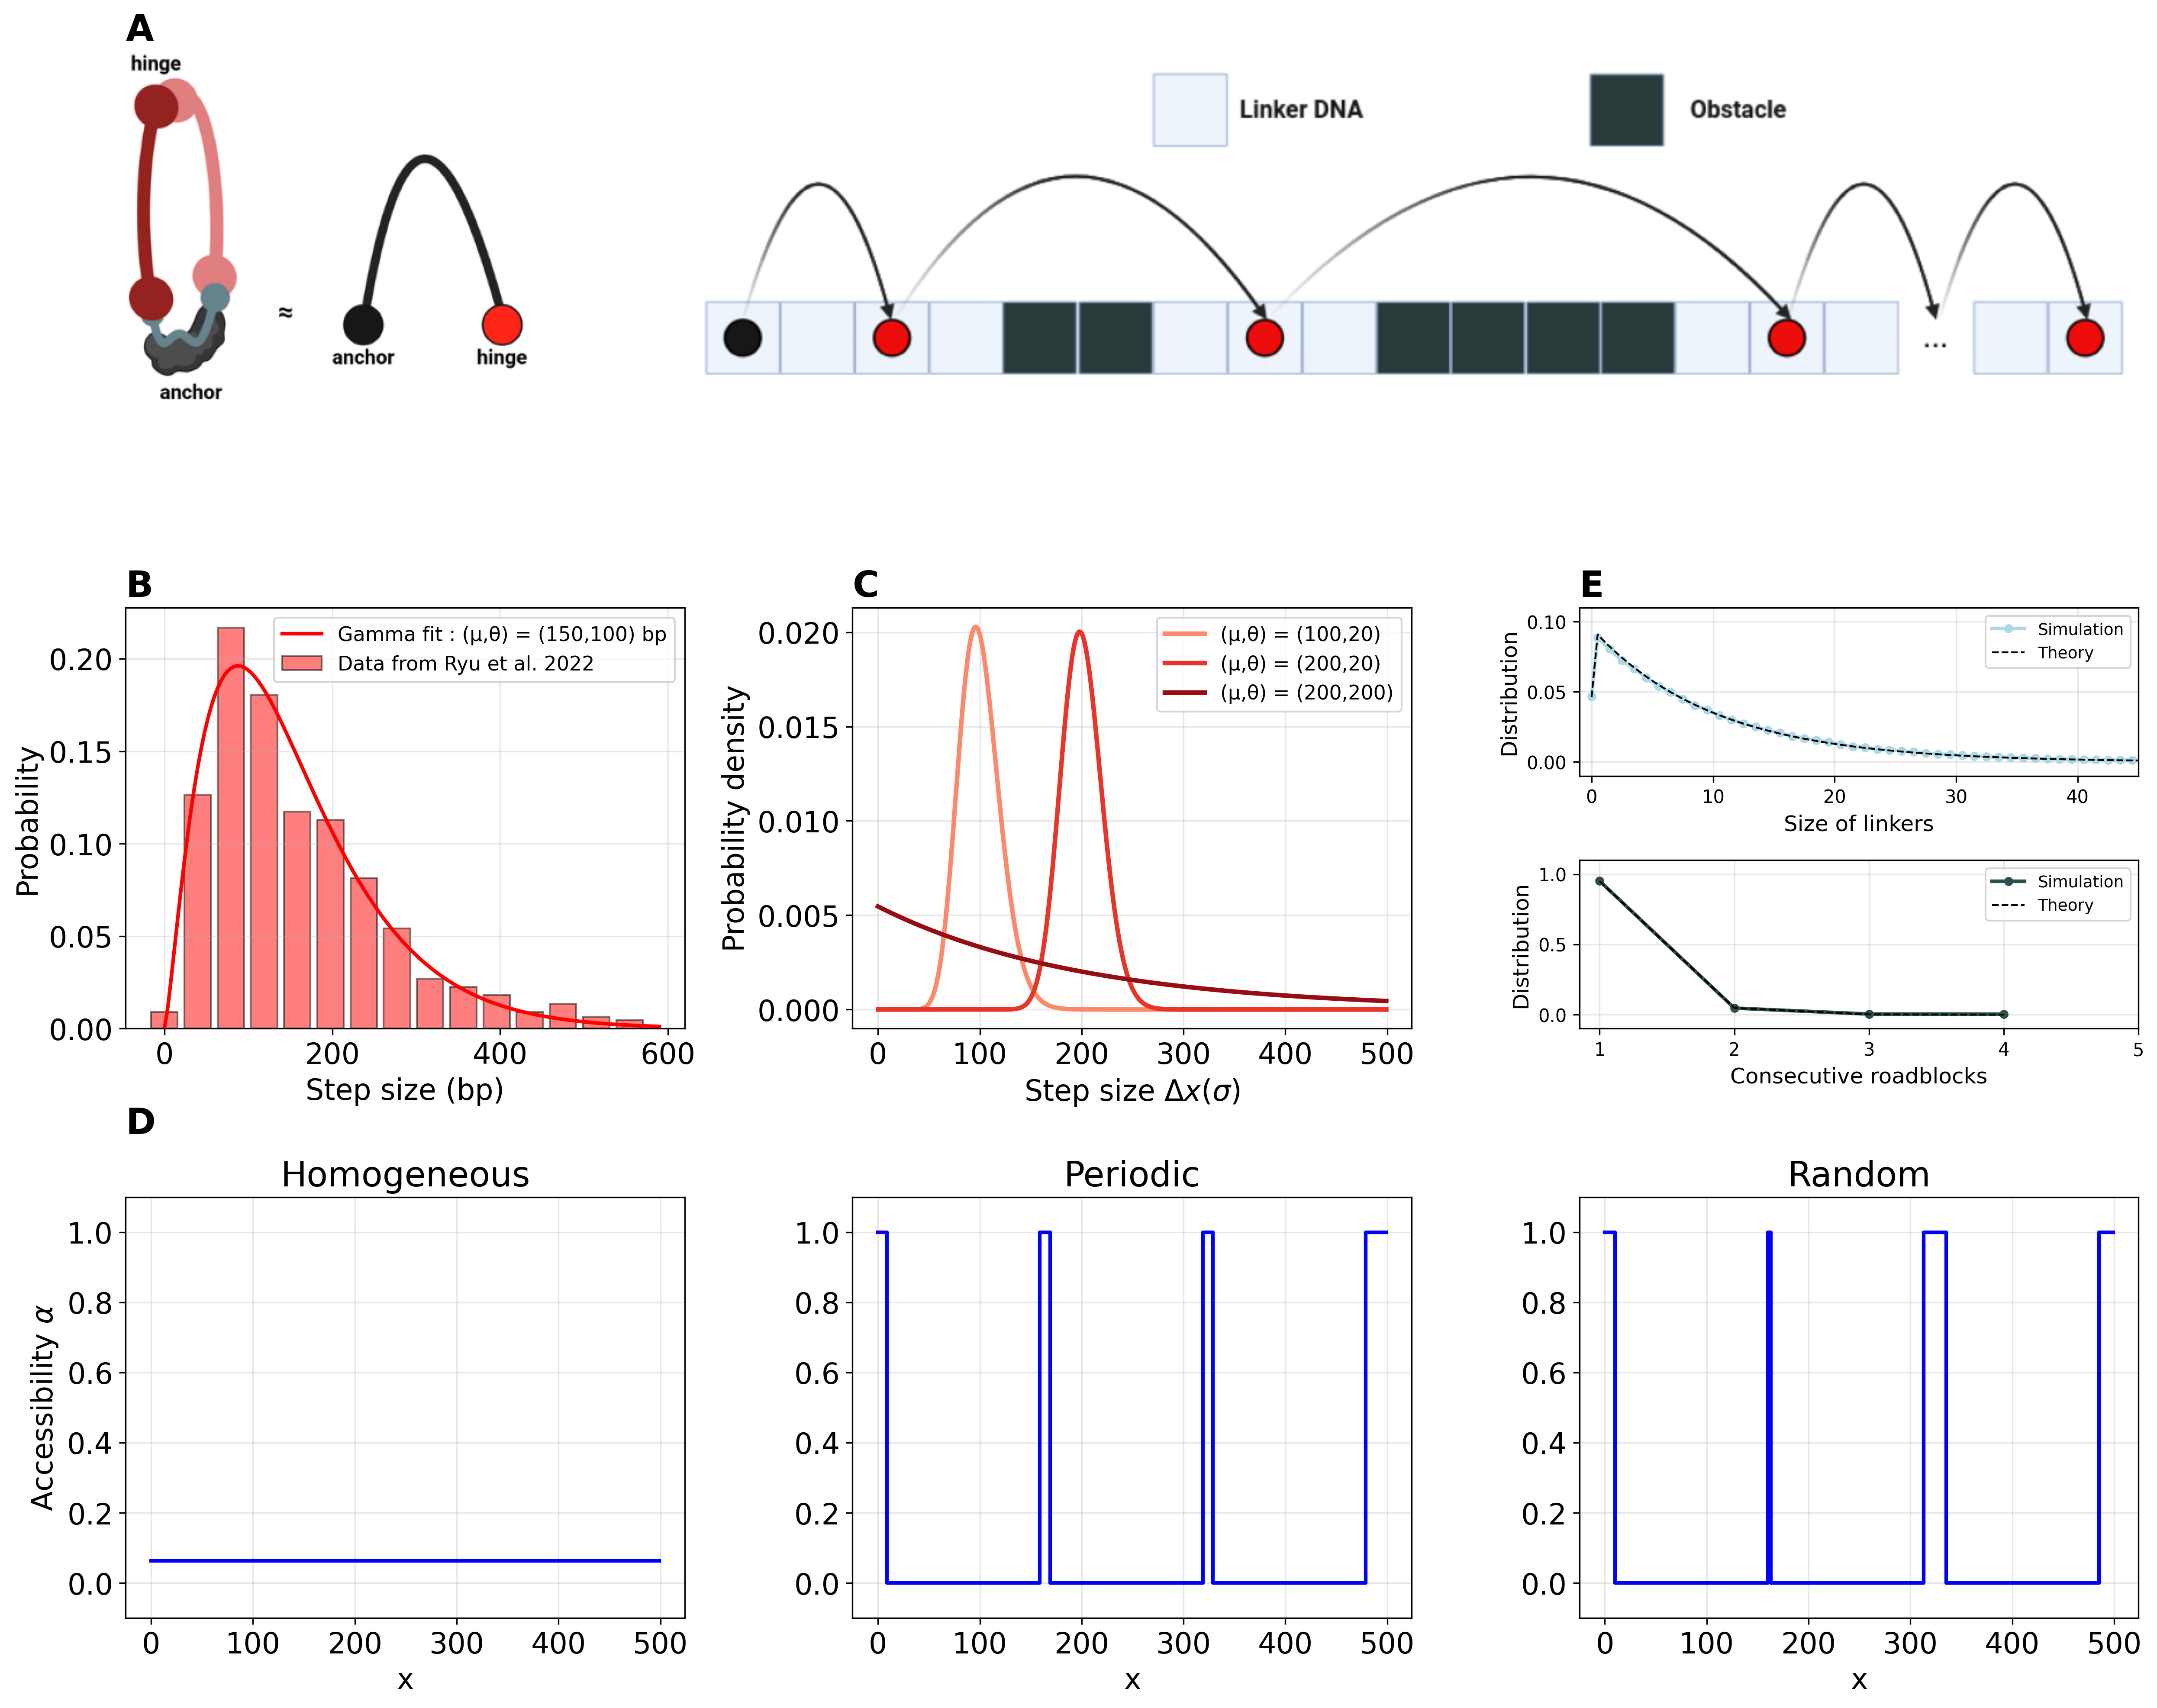

In [8]:
from matplotlib.image import imread
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

fig = plt.figure(figsize=(20, 16), dpi=300)

gs = fig.add_gridspec(
    nrows=3, ncols=3,
    height_ratios=[1.0, 1.0, 1.0],
    hspace=0.4, wspace=0.3
)

# ───────────────────────────────────────────
# Row 1 : A (full width)
# ───────────────────────────────────────────
ax_A = fig.add_subplot(gs[0, :])
ax_A.imshow(imread("fig1_a.png"))
ax_A.axis("off")
ax_A.set_title("A", loc="left", fontweight="bold", fontsize=20)

# ───────────────────────────────────────────
# Row 2 : B, C, E (E split into 2 stacked subplots)
# ───────────────────────────────────────────
ax_B = fig.add_subplot(gs[1, 0])
ax_C = fig.add_subplot(gs[1, 1])

gs_E = gs[1, 2].subgridspec(nrows=2, ncols=1, hspace=0.5)
ax_E1 = fig.add_subplot(gs_E[0, 0])
ax_E2 = fig.add_subplot(gs_E[1, 0])

# --- B ---
ax_B.bar(
    x, y,
    width=(8 / conv),
    edgecolor="black",
    color="red",
    alpha=0.5,
    label="Data from Ryu et al. 2022"
)
ax_B.plot(
    x_fine_2, p * bin_width,
    lw=2, color="red",
    label=f"Gamma fit : (μ,θ) = ({150:.0f},{100:.0f}) bp"
)
ax_B.set_xlabel("Step size (bp)")
ax_B.set_ylabel("Probability")
ax_B.grid(alpha=0.3)
ax_B.legend(fontsize=11)
ax_B.set_title("B", loc="left", fontweight="bold", fontsize=20)

# --- C ---
for (mu_c, theta_c), color in zip(params, colors):
    p_c = proba_gamma(mu=mu_c, theta=theta_c, L=x_fine)
    ax_C.plot(
        x_fine, p_c,
        lw=2.5, color=color,
        label=f"(μ,θ) = ({mu_c},{theta_c})"
    )
ax_C.set_xlabel(r"Step size $ \Delta x(\sigma)$")
ax_C.set_ylabel("Probability density")
ax_C.grid(True, alpha=0.3)
ax_C.legend(loc="upper right", ncols=1, fontsize=11)
ax_C.set_title("C", loc="left", fontweight="bold", fontsize=20)

# --- E1 : linkers ---
theory_distrib_link = th_linkers(link_points[1:], lmoy)

ax_E1.plot(
    link_points[:-1], link_distrib,
    label="Simulation", color="lightblue",
    alpha=1, marker="o", lw=2, markersize=4
)
ax_E1.plot(
    link_points, theory_distrib_link,
    label="Theory", color="black", 
    ls="--", lw=1
)
ax_E1.set_xlabel("Size of linkers", fontsize=12)
ax_E1.set_ylabel("Distribution", fontsize=12)
ax_E1.set_xlim([-1, 45])
ax_E1.set_ylim([-0.010, 0.110])
ax_E1.grid(True, alpha=0.3)
ax_E1.legend(loc="upper right", fontsize=9)
ax_E1.tick_params(labelsize=10)
ax_E1.set_title("E", loc="left", fontweight="bold", fontsize=20)

# --- E2 : roadblocks ---
theory_distrib_road = th_roadblocks(roadblocks_points, lmoy)

ax_E2.plot(
    roadblocks_points, roadblocks_distrib,
    label="Simulation", color="darkslategray",
    alpha=1, marker="o", lw=2, markersize=4
)
ax_E2.plot(
    roadblocks_points, theory_distrib_road,
    label="Theory", color="black", 
    ls="--", lw=1
)
ax_E2.set_xticks(np.arange(1, 6, 1, dtype=int))
ax_E2.set_ylim([-0.10, 1.10])
ax_E2.set_xlabel("Consecutive roadblocks", fontsize=12)
ax_E2.set_ylabel("Distribution", fontsize=12)
ax_E2.grid(True, alpha=0.3)
ax_E2.legend(loc="upper right", fontsize=9)
ax_E2.tick_params(labelsize=10)

# ───────────────────────────────────────────
# Row 3 : D (3 sub-panels, full width)
# ───────────────────────────────────────────
ax_D1 = fig.add_subplot(gs[2, 0])
ax_D2 = fig.add_subplot(gs[2, 1])
ax_D3 = fig.add_subplot(gs[2, 2])

ax_D1.plot(chrom, obs_1, c="b", lw=2)
ax_D1.set_title("Homogeneous")
ax_D1.set_xlabel("x")
ax_D1.set_ylabel(r"Accessibility $\alpha$")
ax_D1.set_ylim([-0.1, 1.1])
ax_D1.grid(True, alpha=0.3)

ax_D2.step(chrom, obs_2, c="b", lw=2)
ax_D2.set_title("Periodic")
ax_D2.set_xlabel("x")
ax_D2.set_ylim([-0.1, 1.1])
ax_D2.grid(True, alpha=0.3)

ax_D3.step(chrom, obs_3, c="b", lw=2)
ax_D3.set_title("Random")
ax_D3.set_xlabel("x")
ax_D3.set_ylim([-0.1, 1.1])
ax_D3.grid(True, alpha=0.3)

ax_D1.text(
    -0.00, 1.15, "D",
    transform=ax_D1.transAxes,
    fontweight="bold", fontsize=20
)

plt.savefig("fig1_final.png", bbox_inches="tight", dpi=1200)
plt.show()

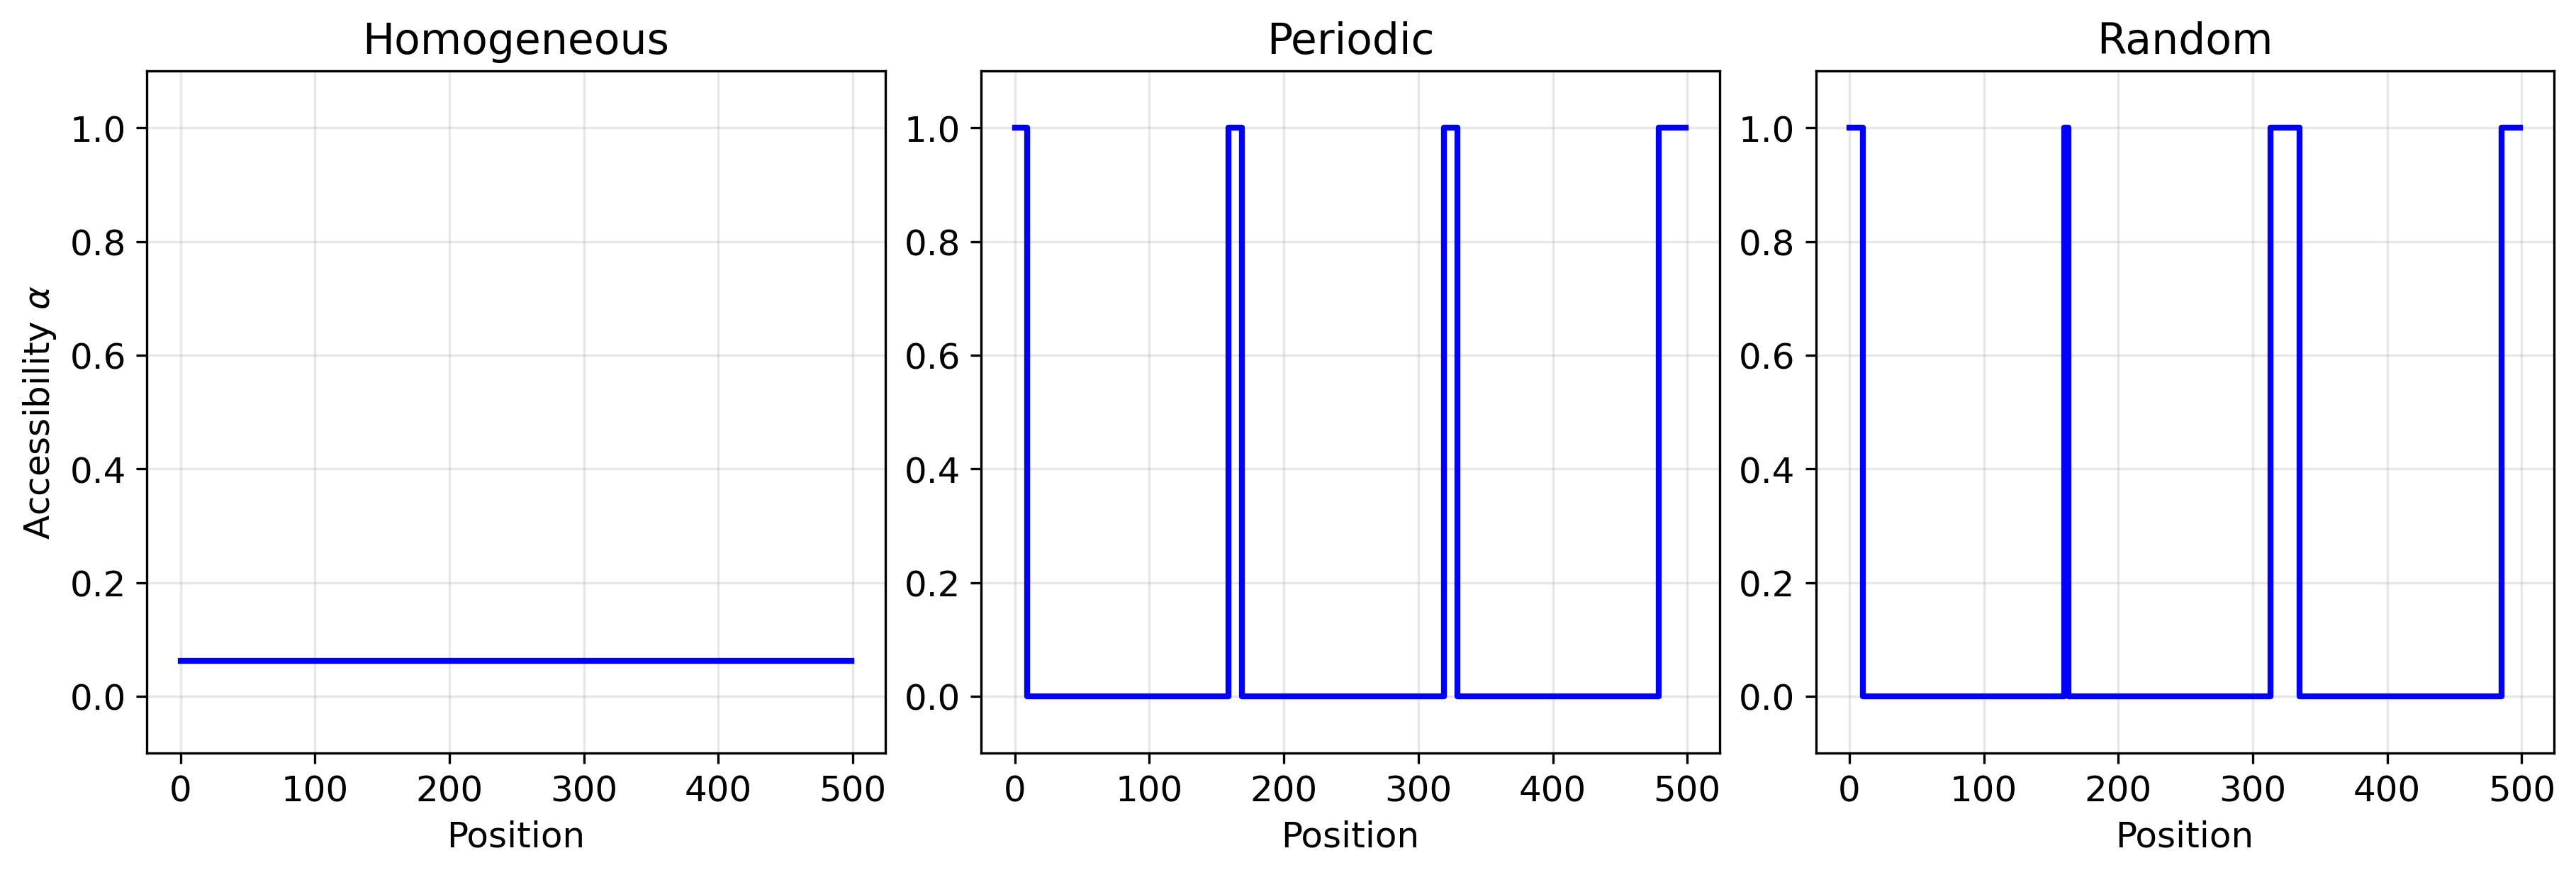

In [9]:
import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 12

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 4),
    dpi=300,
    constrained_layout=True
)

ax_D1, ax_D2, ax_D3 = axes

# --- Homogeneous ---
ax_D1.plot(chrom, obs_1, c="b", lw=2)
ax_D1.set_title("Homogeneous")
ax_D1.set_xlabel("Position")
ax_D1.set_ylabel(r"Accessibility $\alpha$")
ax_D1.set_ylim([-0.1, 1.1])
ax_D1.grid(True, alpha=0.3)

# --- Periodic ---
ax_D2.step(chrom, obs_2, c="b", lw=2)
ax_D2.set_title("Periodic")
ax_D2.set_xlabel("Position")
ax_D2.set_ylim([-0.1, 1.1])
ax_D2.grid(True, alpha=0.3)

# --- Random ---
ax_D3.step(chrom, obs_3, c="b", lw=2)
ax_D3.set_title("Random")
ax_D3.set_xlabel("Position")
ax_D3.set_ylim([-0.1, 1.1])
ax_D3.grid(True, alpha=0.3)

# ax_D1.text(
#     -0.10, 1.08, "D",
#     transform=ax_D1.transAxes,
#     fontsize=20,
#     fontweight="bold"
# )

plt.savefig("fig_D.png", dpi=1200, bbox_inches="tight")
plt.show()

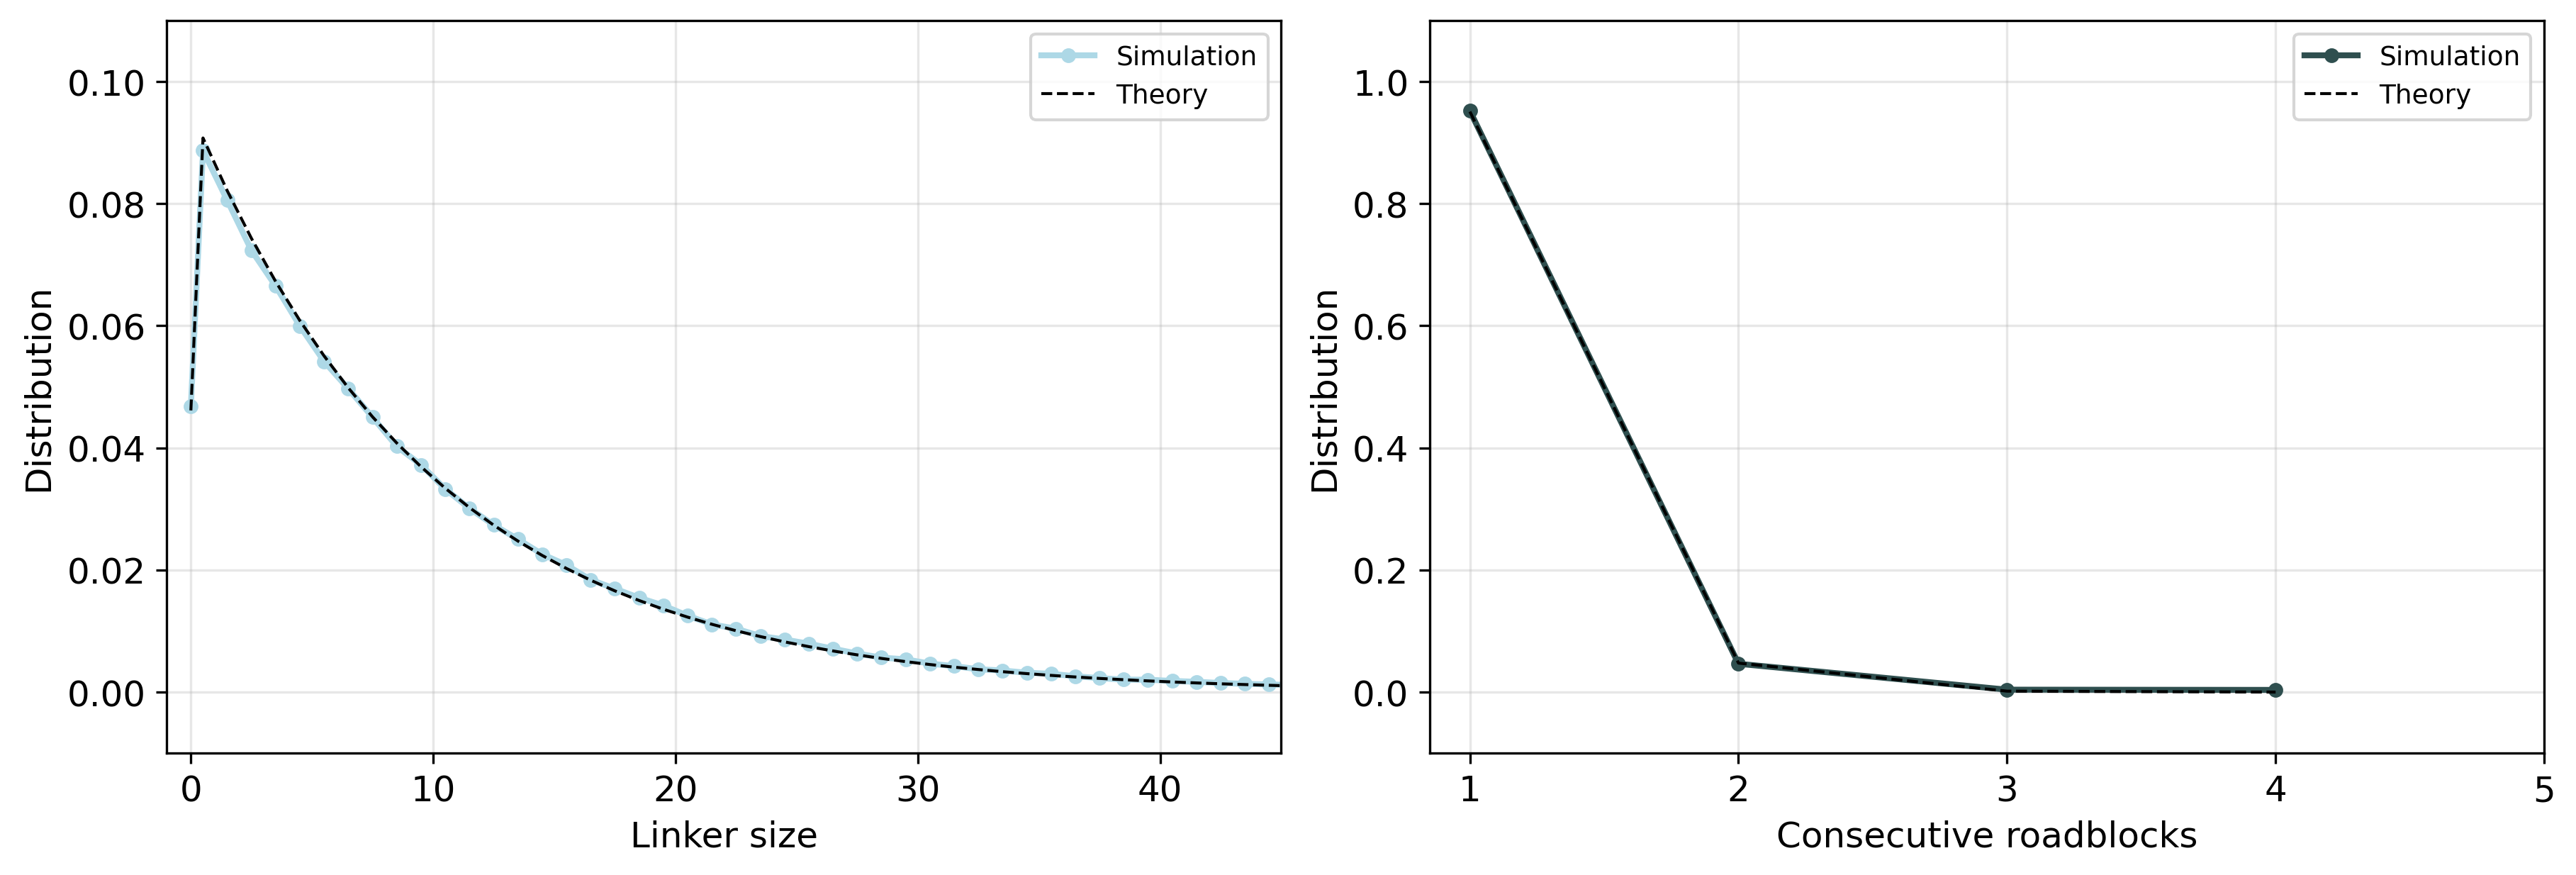

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax_E1, ax_E2) = plt.subplots(
    1, 2,
    figsize=(12, 4),
    dpi=300,
    constrained_layout=True
)

# --- Linkers ---
theory_distrib_link = th_linkers(link_points[1:], lmoy)

ax_E1.plot(
    link_points[:-1], link_distrib,
    label="Simulation",
    color="lightblue",
    marker="o",
    lw=2,
    markersize=4
)
ax_E1.plot(
    link_points,
    theory_distrib_link,
    label="Theory",
    color="black",
    ls="--",
    lw=1
)

ax_E1.set_xlabel("Linker size")
ax_E1.set_ylabel("Distribution")
ax_E1.set_xlim([-1, 45])
ax_E1.set_ylim([-0.010, 0.110])
ax_E1.grid(True, alpha=0.3)
ax_E1.legend(fontsize=9)
# ax_E1.set_title("E", loc="left", fontweight="bold", fontsize=20)

# --- Roadblocks ---
theory_distrib_road = th_roadblocks(roadblocks_points, lmoy)

ax_E2.plot(
    roadblocks_points,
    roadblocks_distrib,
    label="Simulation",
    color="darkslategray",
    marker="o",
    lw=2,
    markersize=4
)
ax_E2.plot(
    roadblocks_points,
    theory_distrib_road,
    label="Theory",
    color="black",
    ls="--",
    lw=1
)

ax_E2.set_xticks(np.arange(1, 6, 1))
ax_E2.set_ylim([-0.10, 1.10])
ax_E2.set_xlabel("Consecutive roadblocks")
ax_E2.set_ylabel("Distribution")
ax_E2.grid(True, alpha=0.3)
ax_E2.legend(fontsize=9)

plt.savefig("fig_E.png", dpi=1200, bbox_inches="tight")
plt.show()

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from nucleo.simulation.probabilities import proba_gamma

plt.rcParams["font.size"] = 12

x_fine = np.arange(0, 500, 1)
params = [
    (100, 20),
    (200, 20),
    (200, 200),
]

cmap = plt.cm.Reds
colors = [cmap(0.4), cmap(0.65), cmap(0.9)]

plt.figure(figsize=(8,6), dpi=1200)

for (mu, theta), color in zip(params, colors):
    pb = proba_gamma(mu=mu, theta=theta, L=x_fine)
    
    plt.plot(
        x_fine,
        pb,
        lw=2.5,
        color=color,
        label=f"(μ,θ) = ({mu},{theta})"
    )

plt.xlabel(r"Step size $(\sigma)$")
plt.ylabel("Probability density")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right", ncols=1)
plt.tight_layout()
plt.show()

# .